# NIFTY Options Backtest — Real Data (NSE Bhav Copy)

| What | Source |
|------|--------|
| **Entry price** | Real option OPEN from NSE F&O Bhav Copy |
| **Implied IV** | Back-calculated from real entry price |
| **Exit simulation** | NIFTY spot minute cache (Kite) + real IV |
| **Expiry** | Thursday before 2025-09-02 · Tuesday from 2025-09-02 |

**Filters applied:**
- `SIGNAL_MODE = BEARISH_ONLY` — BULLISH signals have no edge in real data
- **Monday filter** — no trades on Mondays (US/SGX data is 3 days stale; base rate = 50.7%, no edge)
- **Event filter** — no trades on scheduled high-impact event days (elections, RBI policy, Budget, FOMC)
- **SL=30%, TP=40%** — optimal from grid search (Rs935 avg/trade vs Rs894 at 40/40)

If a bhav copy is unavailable the trade is **skipped** (never synthesised).
Bhav copies cached in `bhav_cache/`. Run cells 1 → 2 → 3 → 4 → 5 → 6

In [82]:
# Cell 1: Imports & Config
import numpy as np
import pandas as pd
import pickle, requests, zipfile, io, time as _time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import date, timedelta, datetime
from datetime import time as dtime
from scipy.stats import norm as _norm
from scipy.optimize import newton
import warnings
warnings.filterwarnings('ignore')

# ── Trade parameters (grid-search optimised for BEARISH) ──────────────────────
STOP_LOSS_PCT      = 0.20   # 30% — tighter SL beats 40% for BEARISH (grid search)
PROFIT_TARGET_PCT  = 0.60   # 40% — keep TP unchanged
LOT_SIZE           = 75
STRIKE_STEP        = 50
STRIKES_OTM        = 1
RISK_FREE_RATE     = 0.065
BROKERAGE          = 80
BACKTEST_DAYS      = 252 * 3
BASE_RATE          = 54.5
DTE0_MAX_LOTS      = 10000
MAX_LOTS           = 10000

# BEARISH_ONLY: BULLISH signals showed no edge in real-data backtest
SIGNAL_MODE = 'Bearish'

# NSE shifted NIFTY weekly expiry Thursday -> Tuesday effective 2025-09-02
EXPIRY_CHANGE_DATE = date(2025, 9, 2)

# ── Event filter — do NOT trade on these days ─────────────────────────────────
# These are days where the market's first-hour move is event-driven,
# not driven by overnight global signals. IV is elevated; edge disappears.
# Update each year: RBI MPC dates, Budget, election result days, key FOMC days.
EVENT_DAYS = {
    # Indian elections / results
    date(2024, 6, 4),   # Lok Sabha election results — caused -Rs17k in 2 days
    date(2024, 6, 5),
    # Union Budget
    date(2024, 2, 1),
    date(2025, 2, 1),
    date(2026, 2, 1),
    # RBI MPC decisions (bi-monthly — add dates as they are announced)
    date(2024, 4, 5),  date(2024, 6, 7),  date(2024, 8, 8),
    date(2024, 10, 9), date(2024, 12, 6),
    date(2025, 2, 7),  date(2025, 4, 9),  date(2025, 6, 6),
    date(2025, 8, 6),  date(2025, 10, 8), date(2025, 12, 5),
    date(2026, 2, 6),  date(2026, 4, 3),
    # State election result days (major states)
    date(2023, 12, 3),  # MP / Rajasthan / Chhattisgarh results
    date(2024, 11, 23), # Maharashtra results
    date(2025, 2, 8),   # Delhi results
}

# NSE trading holidays
NSE_HOLIDAYS = {
    date(2023,1,26), date(2023,3,7),  date(2023,4,4),  date(2023,4,7),
    date(2023,4,14), date(2023,5,1),  date(2023,6,28), date(2023,8,15),
    date(2023,9,19), date(2023,10,2), date(2023,10,24),date(2023,11,14),
    date(2023,11,27),date(2023,12,25),
    date(2024,1,22), date(2024,1,26), date(2024,3,25), date(2024,4,9),
    date(2024,4,11), date(2024,4,14), date(2024,4,17), date(2024,4,21),
    date(2024,5,1),  date(2024,5,23), date(2024,6,17), date(2024,7,17),
    date(2024,8,15), date(2024,10,2), date(2024,10,14),date(2024,11,1),
    date(2024,11,15),date(2024,12,25),
    date(2025,2,26), date(2025,3,14), date(2025,3,31), date(2025,4,10),
    date(2025,4,14), date(2025,4,18), date(2025,5,1),  date(2025,6,6),
    date(2025,7,29), date(2025,8,15), date(2025,8,27), date(2025,10,2),
    date(2025,10,20),date(2025,10,21),date(2025,11,5), date(2025,12,25),
    date(2026,1,26), date(2026,3,20), date(2026,4,3),  date(2026,4,14),
    date(2026,5,1),  date(2026,8,15), date(2026,10,2), date(2026,11,9),
    date(2026,12,25),
}

# Paths
BASE         = Path.cwd() if (Path.cwd()/'v2'/'v2_aligned_dataset.csv').exists() else Path.cwd().parent
ALIGNED_CSV  = BASE / 'v2' / 'v2_aligned_dataset.csv'
MINUTE_CACHE = BASE / 'v2' / 'kite_minute_cache'
SIGNALS_CSV  = BASE / 'v2' / 'v2_reliable_signals.csv'
BHAV_CACHE   = BASE / 'backtesting_true_data' / 'bhav_cache'
OUTPUT_DIR   = BASE / 'backtesting_true_data' / 'backtest_outputs'
BHAV_CACHE.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'BASE        : {BASE}')
print(f'Signal mode : {SIGNAL_MODE}  |  SL={STOP_LOSS_PCT:.0%}  TP={PROFIT_TARGET_PCT:.0%}')
print(f'Monday filter : ON  (no trades on Mondays)')
print(f'Event filter  : ON  ({len(EVENT_DAYS)} event days blocked)')

BASE        : c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research
Signal mode : Bearish  |  SL=20%  TP=60%
Monday filter : ON  (no trades on Mondays)
Event filter  : ON  (21 event days blocked)


In [83]:
# Cell 2: Load dataset + NIFTY spot minute cache
aligned = pd.read_csv(ALIGNED_CSV, parse_dates=['india_date'])
aligned = aligned.sort_values('india_date').reset_index(drop=True)
aligned['VIX_INDIA_level'] = aligned['VIX_INDIA_level'].ffill().bfill()

backtest_df = aligned.tail(BACKTEST_DAYS).copy().reset_index(drop=True)
start_date  = backtest_df['india_date'].iloc[0].date()
end_date    = backtest_df['india_date'].iloc[-1].date()

reliable    = pd.read_csv(SIGNALS_CSV)
top_bearish = (reliable[reliable['P_Down'] > BASE_RATE]
               .sort_values('Edge_pp', ascending=False).head(3).reset_index(drop=True))
top_bullish = (reliable[reliable['P_Down'] < (100 - BASE_RATE)]
               .sort_values('P_Down', ascending=True).head(3).reset_index(drop=True))

print(f'Backtest period : {start_date}  to  {end_date}  ({len(backtest_df)} days)')
print('\nTop 3 BEARISH signal combos:')
for _, r in top_bearish.iterrows():
    print(f'  [{int(r["Level"])}] {r["Signal"]:<55}  P(DOWN)={r["P_Down"]:.1f}%  Edge=+{r["Edge_pp"]:.1f}%  N={int(r["N"])}')

# Load NIFTY spot minute data
all_chunks = []
for pkl_path in sorted(MINUTE_CACHE.glob('minute_256265_*.pkl')):
    with open(pkl_path, 'rb') as f:
        chunk = pickle.load(f)
    chunk.index = pd.to_datetime(chunk.index)
    if chunk.index.tzinfo is None:
        chunk.index = chunk.index.tz_localize('Asia/Kolkata')
    lo = (pd.Timestamp(start_date) - pd.Timedelta(days=1)).tz_localize('Asia/Kolkata')
    hi = (pd.Timestamp(end_date)   + pd.Timedelta(days=1)).tz_localize('Asia/Kolkata')
    mask = (chunk.index >= lo) & (chunk.index <= hi)
    if mask.sum() > 0:
        all_chunks.append(chunk[mask])

if all_chunks:
    minute_all     = pd.concat(all_chunks).sort_index()
    _trading_dates = set(minute_all.index.normalize().map(lambda ts: ts.date()))
    print(f'\nNIFTY spot minute data: {len(minute_all):,} rows  ({minute_all.index[0].date()} to {minute_all.index[-1].date()})')
else:
    minute_all = pd.DataFrame()
    _trading_dates = set()
    print('WARNING: No NIFTY spot minute cache found.')

Backtest period : 2023-03-31  to  2026-04-02  (740 days)

Top 3 BEARISH signal combos:
  [4] Gap Up + Prev India DOWN + US UP + SGX UP                P(DOWN)=74.6%  Edge=+20.0%  N=67
  [4] Gap Up + Prev India DOWN + SGX UP + DAX UP               P(DOWN)=74.1%  Edge=+19.4%  N=54
  [4] Gap Up + Prev India DOWN + SGX UP + VIX Falling          P(DOWN)=72.7%  Edge=+18.1%  N=44

NIFTY spot minute data: 554,992 rows  (2023-03-31 to 2026-04-02)


In [84]:
# Cell 3: NSE Bhav Copy downloader + all helpers
#
# NSE has two URL formats:
#   Old (pre-Jul 2024): archives.nseindia.com/content/historical/DERIVATIVES/...
#   New (Jul 2024+):    nsearchives.nseindia.com/content/fo/BhavCopy_FOAll_YYYYMMDD_1.csv.zip
#
# Both require a properly warmed NSE session (cookies from www.nseindia.com).
# The session is initialised once and reused for all downloads.

_nse_session = None

def _get_nse_session():
    global _nse_session
    if _nse_session is not None:
        return _nse_session
    s = requests.Session()
    s.headers.update({
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.9',
        'Accept-Encoding': 'gzip, deflate, br',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1',
        'Sec-Fetch-Dest': 'document',
        'Sec-Fetch-Mode': 'navigate',
        'Sec-Fetch-Site': 'none',
        'Referer': 'https://www.nseindia.com/',
    })
    # Warm up: hit main page, then FO data page to populate Akamai cookies
    for warmup_url in [
        'https://www.nseindia.com',
        'https://www.nseindia.com/market-data/futures-and-options-market-data',
    ]:
        try:
            s.get(warmup_url, timeout=12)
            _time.sleep(0.5)
        except Exception:
            pass
    _nse_session = s
    return s

def _parse_bhav_zip(raw_bytes):
    """Parse bhav copy ZIP -> DataFrame[expiry, strike, opt_type, open] for NIFTY only."""
    try:
        with zipfile.ZipFile(io.BytesIO(raw_bytes)) as z:
            df = pd.read_csv(z.open(z.namelist()[0]))
    except Exception:
        return None
    df.columns = df.columns.str.strip()
    if 'TckrSymb' in df.columns:        # New NSE format
        df = df.rename(columns={'TckrSymb':'symbol','XpryDt':'expiry_raw',
                                 'StrkPric':'strike','OptnTp':'opt_type','OpnPric':'open'})
        df['expiry'] = pd.to_datetime(df['expiry_raw'], errors='coerce').dt.date
    elif 'SYMBOL' in df.columns:        # Old NSE format
        df = df.rename(columns={'SYMBOL':'symbol','EXPIRY_DT':'expiry_raw',
                                 'STRIKE_PR':'strike','OPTION_TYP':'opt_type','OPEN':'open'})
        df['expiry'] = pd.to_datetime(df['expiry_raw'], dayfirst=True, errors='coerce').dt.date
    else:
        return None
    df = df[df['symbol'].astype(str).str.strip() == 'NIFTY']
    df = df[df['opt_type'].isin(['CE','PE'])]
    df['strike'] = pd.to_numeric(df['strike'], errors='coerce')
    df['open']   = pd.to_numeric(df['open'],   errors='coerce')
    return df[['expiry','strike','opt_type','open']].dropna(subset=['expiry','strike','open']).copy()

_bhav_mem = {}

def load_bhav(trade_date):
    """Return NIFTY F&O bhav copy for trade_date as DataFrame, or None."""
    if trade_date in _bhav_mem:
        return _bhav_mem[trade_date]
    cache_path = BHAV_CACHE / f'{trade_date}.pkl'
    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            result = pickle.load(f)
        _bhav_mem[trade_date] = result
        return result

    dd       = trade_date.strftime('%d')
    yyyy     = trade_date.strftime('%Y')
    mon      = trade_date.strftime('%b').upper()
    yyyymmdd = trade_date.strftime('%Y%m%d')

    urls = [
        # New format (Jul 2024 onwards)
        f'https://nsearchives.nseindia.com/content/fo/BhavCopy_FOAll_{yyyymmdd}_1.csv.zip',
        # Old format (works for older dates)
        f'https://archives.nseindia.com/content/historical/DERIVATIVES/{yyyy}/{mon}/fo{dd}{mon}{yyyy}bhav.csv.zip',
        # Alternative old format path
        f'https://www.nseindia.com/content/historical/DERIVATIVES/{yyyy}/{mon}/fo{dd}{mon}{yyyy}bhav.csv.zip',
    ]

    s = _get_nse_session(); result = None
    for url in urls:
        try:
            r = s.get(url, timeout=30)
            if r.status_code == 200 and len(r.content) > 1000:
                df = _parse_bhav_zip(r.content)
                if df is not None and len(df) > 0:
                    result = df; _time.sleep(0.25); break
        except Exception:
            continue

    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    _bhav_mem[trade_date] = result
    return result

def get_option_open(trade_date, expiry, strike, opt_type):
    """Return real OPEN price from bhav copy for (expiry, strike, opt_type), or None."""
    bhav = load_bhav(trade_date)
    if bhav is None:
        return None
    mask = ((bhav['expiry'] == expiry) &
            (bhav['strike'].round(0).astype(int) == int(strike)) &
            (bhav['opt_type'] == opt_type))
    rows = bhav[mask]
    if rows.empty:
        return None
    price = float(rows.iloc[0]['open'])
    return price if price > 0 else None

# Expiry helpers
def _is_trading_day(d):
    if d.weekday() >= 5: return False
    if d in NSE_HOLIDAYS: return False
    if _trading_dates: return d in _trading_dates
    return True

def get_expiry(trade_date):
    """Thursday expiry pre-2025-09-02; Tuesday expiry from 2025-09-02.
    Rolls back to previous trading day if expiry falls on a holiday."""
    days_ahead = (1 - trade_date.weekday()) % 7 if trade_date >= EXPIRY_CHANGE_DATE \
                 else (3 - trade_date.weekday()) % 7
    expiry = trade_date + timedelta(days=days_ahead)
    for _ in range(7):
        if _is_trading_day(expiry): break
        expiry -= timedelta(days=1)
    return expiry

# Black-Scholes + IV
def bs_price(S, K, T, r, sigma, opt_type='CE'):
    if T <= 1e-7: return max(0.0,S-K) if opt_type=='CE' else max(0.0,K-S)
    sq=sigma*np.sqrt(T); d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/sq; d2=d1-sq
    if opt_type=='CE': return float(S*_norm.cdf(d1)-K*np.exp(-r*T)*_norm.cdf(d2))
    return float(K*np.exp(-r*T)*_norm.cdf(-d2)-S*_norm.cdf(-d1))

def implied_vol(S, K, T, r, market_price, opt_type):
    if T<=1e-7 or market_price<=0: return None
    intrinsic=max(0.0,S-K) if opt_type=='CE' else max(0.0,K-S)
    if market_price < intrinsic-1.0: return None
    try:
        sol=newton(lambda sig: bs_price(S,K,T,r,max(sig,1e-6),opt_type)-market_price, x0=0.20,tol=1e-5,maxiter=100)
        return float(sol) if 0.01<=sol<=5.0 else None
    except: return None

print('Helpers ready.')
print(f'Bhav cache : {BHAV_CACHE}')
print('Initialising NSE session...', end=' ', flush=True)
_get_nse_session()
print('done.')

Helpers ready.
Bhav cache : c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\backtesting_true_data\bhav_cache
Initialising NSE session... done.


In [85]:
# Cell 4: Signal classification
GAP_THR = 0.0015; GAP_LARGE = 0.0050

def compute_signals(row):
    return {
        'Gap Up'         : float(row['gap_pct']) >  GAP_THR,
        'Gap Up Strong'  : float(row['gap_pct']) >  GAP_LARGE,
        'Gap Down'       : float(row['gap_pct']) < -GAP_THR,
        'Prev India UP'  : float(row['prev_india_ret']) > 0,
        'Prev India DOWN': float(row['prev_india_ret']) < 0,
        'US UP'          : float(row['SP500_ret']) > 0,
        'US DOWN'        : float(row['SP500_ret']) < 0,
        'SGX UP'         : float(row['SGX_ret']) > 0,
        'SGX DOWN'       : float(row['SGX_ret']) < 0,
        'DAX UP'         : float(row['DAX_ret']) > 0,
        'VIX Rising'     : float(row['VIX_US_ret']) > 0.03,
        'VIX Falling'    : float(row['VIX_US_ret']) < 0,
        'VIX Spike'      : float(row['VIX_US_ret']) > 0.05,
    }

def check_combo(signals, signal_str):
    return all(signals.get(s.strip(), False) for s in signal_str.split('+'))

bear_combos = list(top_bearish['Signal'])
bull_combos = list(top_bullish['Signal']) if SIGNAL_MODE != 'BEARISH_ONLY' else []

trade_days = []
skipped_monday = 0
skipped_event  = 0

for _, row in backtest_df.iterrows():
    d    = row['india_date'].date()
    sigs = compute_signals(row)

    # Monday filter — US/SGX data is 3 days stale; no directional edge on Mondays
    if d.weekday() == 0:   # Monday
        skipped_monday += 1
        trade_days.append({'india_date':row['india_date'],'india_open':float(row['india_open']),
            'gap_pct':float(row['gap_pct']),'vix_india':float(row['VIX_INDIA_level']),
            'dir_60':int(row['dir_60']),'ret_60':float(row['ret_60']),
            'action':'MONDAY_SKIP','combo_fired':None})
        continue

    # Event filter
    if d in EVENT_DAYS:
        skipped_event += 1
        trade_days.append({'india_date':row['india_date'],'india_open':float(row['india_open']),
            'gap_pct':float(row['gap_pct']),'vix_india':float(row['VIX_INDIA_level']),
            'dir_60':int(row['dir_60']),'ret_60':float(row['ret_60']),
            'action':'EVENT_SKIP','combo_fired':None})
        continue

    bear_fired = [c for c in bear_combos if check_combo(sigs,c)] if SIGNAL_MODE != 'BULLISH_ONLY' else []
    bull_fired = [c for c in bull_combos if check_combo(sigs,c)] if SIGNAL_MODE != 'BEARISH_ONLY' else []
    if   bear_fired and bull_fired: action, combo = 'CONFLICT',   None
    elif bear_fired:                action, combo = 'BEARISH',    bear_fired[0]
    elif bull_fired:                action, combo = 'BULLISH',    bull_fired[0]
    else:                           action, combo = 'NO_SIGNAL',  None

    trade_days.append({'india_date':row['india_date'],'india_open':float(row['india_open']),
        'gap_pct':float(row['gap_pct']),'vix_india':float(row['VIX_INDIA_level']),
        'dir_60':int(row['dir_60']),'ret_60':float(row['ret_60']),
        'action':action,'combo_fired':combo})

trade_days_df = pd.DataFrame(trade_days)

print(f'Signal distribution across {len(backtest_df)} backtest days:')
for k,v in trade_days_df['action'].value_counts().items():
    print(f'  {k:<15}: {v:>3}  ({v/len(trade_days_df)*100:.1f}%)')
print(f'  Monday filtered  : {skipped_monday}')
print(f'  Event filtered   : {skipped_event}')
print(f"\nTrade-able days : {(trade_days_df['action'].isin(['BEARISH','BULLISH'])).sum()}")

Signal distribution across 740 backtest days:
  NO_SIGNAL      : 453  (61.2%)
  MONDAY_SKIP    : 146  (19.7%)
  BULLISH        :  72  (9.7%)
  BEARISH        :  52  (7.0%)
  EVENT_SKIP     :  17  (2.3%)
  Monday filtered  : 146
  Event filtered   : 17

Trade-able days : 124


In [86]:
# Cell 5: Run backtest
#  Entry  = real option OPEN from NSE bhav copy
#  IV     = back-calculated from real entry price
#  Exit   = NIFTY spot minute cache + real IV (BS-simulated intraday path)
#  Skip if bhav copy unavailable (never substitute BS for entry)

def simulate_trade(trade_date, action, nifty_open, vix_india, spot_df):
    if isinstance(trade_date, pd.Timestamp):
        trade_date = trade_date.date()
    expiry = get_expiry(trade_date)
    dte    = (expiry - trade_date).days
    atm    = round(nifty_open/STRIKE_STEP)*STRIKE_STEP
    strike = atm - STRIKE_STEP*STRIKES_OTM if action=='BEARISH' else atm + STRIKE_STEP*STRIKES_OTM
    opt    = 'PE' if action=='BEARISH' else 'CE'

    entry_price = get_option_open(trade_date, expiry, int(strike), opt)
    if entry_price is None:
        return None

    expiry_dt = datetime.combine(expiry, dtime(15,30))
    def tte(t_obj):
        return max((expiry_dt-datetime.combine(trade_date,t_obj)).total_seconds(),0.0)/(365.25*24*3600)

    iv = implied_vol(nifty_open, strike, tte(dtime(9,15)), RISK_FREE_RATE, entry_price, opt)
    if iv is None:
        iv_raw=vix_india/100.0; iv=iv_raw*(1.30 if dte<=2 else 1.15 if dte<=4 else 1.05)

    sl_price=entry_price*(1-STOP_LOSS_PCT); tp_price=entry_price*(1+PROFIT_TARGET_PCT)
    day_min=spot_df[spot_df.index.date==trade_date].between_time('09:16','10:15')
    exit_price=None; exit_reason='10:15 exit'; exit_time='10:15'

    for ts, m in day_min.iterrows():
        spot=float(m['close']); t_now=ts.to_pydatetime().replace(tzinfo=None).time()
        price=bs_price(spot,strike,tte(t_now),RISK_FREE_RATE,iv,opt)
        if price<=sl_price: exit_price,exit_reason,exit_time=sl_price,'Stop Loss',str(t_now)[:5]; break
        if price>=tp_price: exit_price,exit_reason,exit_time=tp_price,'Target Hit',str(t_now)[:5]; break
    if exit_price is None:
        spot_last=float(day_min.iloc[-1]['close']) if len(day_min)>0 else nifty_open
        exit_price=bs_price(spot_last,strike,tte(dtime(10,15)),RISK_FREE_RATE,iv,opt)

    return {'expiry':expiry,'dte':dte,'opt_type':opt,'strike':int(strike),'atm':int(atm),
            'iv_pct':round(iv*100,1),'entry_pts':round(entry_price,2),'exit_pts':round(exit_price,2),
            'exit_reason':exit_reason,'exit_time':exit_time,
            'pnl_pts':round(exit_price-entry_price,2),
            'pnl_rs':round((exit_price-entry_price)*LOT_SIZE-BROKERAGE,2)}

tradeable       = trade_days_df[trade_days_df['action'].isin(['BEARISH','BULLISH'])].copy()
results         = []
skipped_no_bhav = 0
print(f'Running backtest on {len(tradeable)} tradeable days...')
print('(Bhav copies downloaded on first run; subsequent runs use cache)\n')

for idx,(_, trow) in enumerate(tradeable.iterrows(),1):
    d=trow['india_date'].date()
    print(f'  [{idx:>3}/{len(tradeable)}] {d}  {trow["action"]:<8}', end='  ', flush=True)
    res=simulate_trade(d,trow['action'],trow['india_open'],trow['vix_india'],minute_all)
    if res is None:
        skipped_no_bhav+=1; print('SKIPPED (bhav unavailable)'); continue
    actual_dir=int(trow['dir_60']); pred_dir=-1 if trow['action']=='BEARISH' else +1
    print(f'Entry={res["entry_pts"]:.1f}  Exit={res["exit_pts"]:.1f}  P&L={res["pnl_rs"]:+,.0f}  {res["exit_reason"]}')
    results.append({
        'Date':d,'Signal':trow['action'],'Combo':trow['combo_fired'],
        'NIFTY Open':int(round(trow['india_open'])),'Gap%':f"{trow['gap_pct']:+.2%}",
        'Strike':f"{res['strike']} {res['opt_type']}",
        'ATM':res['atm'],'Expiry':res['expiry'],'DTE':res['dte'],'IV%':res['iv_pct'],
        'Entry (pts)':res['entry_pts'],'Exit (pts)':res['exit_pts'],
        'Exit Reason':res['exit_reason'],'Exit Time':res['exit_time'],
        'P&L (pts)':res['pnl_pts'],'P&L (Rs)':res['pnl_rs'],
        'Actual':'DOWN' if actual_dir==-1 else 'UP',
        'Actual Ret%':f"{trow['ret_60']:+.2%}",
        'Correct?':'YES' if pred_dir==actual_dir else 'NO',
    })

results_df=pd.DataFrame(results); total_trades=len(results_df)
print(f'\n{"="*60}')
print(f'  Trades simulated : {total_trades}')
print(f'  Skipped (no bhav): {skipped_no_bhav}')
print(f'  Monday filtered  : {skipped_monday}')
print(f'  Event filtered   : {skipped_event}')
if total_trades>0:
    wins=(results_df['P&L (Rs)']>0).sum()
    print(f'  Win rate         : {wins}/{total_trades}  ({wins/total_trades*100:.1f}%)')
    print(f'  Total P&L 1-lot  : Rs{results_df["P&L (Rs)"].sum():,.0f}')
    print(f'  Avg P&L / trade  : Rs{results_df["P&L (Rs)"].mean():,.0f}')
print(f'  Mode             : {SIGNAL_MODE}  SL={STOP_LOSS_PCT:.0%}  TP={PROFIT_TARGET_PCT:.0%}')
print(f'{"="*60}')

Running backtest on 124 tradeable days...
(Bhav copies downloaded on first run; subsequent runs use cache)

  [  1/124] 2023-04-18  BEARISH   Entry=50.0  Exit=80.1  P&L=+2,172  Target Hit
  [  2/124] 2023-05-18  BEARISH   Entry=25.0  Exit=40.0  P&L=+1,045  Target Hit
  [  3/124] 2023-05-19  BEARISH   Entry=87.0  Exit=139.2  P&L=+3,835  Target Hit
  [  4/124] 2023-05-31  BULLISH   Entry=38.5  Exit=30.8  P&L=-658  Stop Loss
  [  5/124] 2023-06-02  BEARISH   Entry=63.0  Exit=87.4  P&L=+1,748  10:15 exit
  [  6/124] 2023-06-16  BULLISH   Entry=80.0  Exit=104.2  P&L=+1,731  10:15 exit
  [  7/124] 2023-06-23  BULLISH   SKIPPED (bhav unavailable)
  [  8/124] 2023-07-13  BULLISH   Entry=15.0  Exit=12.0  P&L=-305  Stop Loss
  [  9/124] 2023-07-25  BEARISH   Entry=79.9  Exit=105.9  P&L=+1,871  10:15 exit
  [ 10/124] 2023-09-29  BULLISH   Entry=100.0  Exit=108.5  P&L=+562  10:15 exit
  [ 11/124] 2023-10-05  BULLISH   Entry=25.0  Exit=21.7  P&L=-330  10:15 exit
  [ 12/124] 2023-10-10  BULLISH   En

                                                                                      NIFTY OPTIONS BACKTEST — REAL NSE DATA                                                                                      
                                                                 Mode=Bearish  SL=20%  TP=60%  1-OTM  Entry=NSE Bhav Open  Monday+Event filtered                                                                  
      Date  Signal  NIFTY Open   Gap%   Strike  DTE  IV%  Entry (pts)  Exit (pts) Exit Reason Exit Time  P&L (pts)  P&L (Rs) Actual Actual Ret% Correct?
2023-04-18 BEARISH       17767 +0.34% 17700 PE    2 14.7        50.05       80.08  Target Hit     09:50      30.03   2172.25   DOWN      -0.54%      YES
2023-05-18 BEARISH       18288 +0.58% 18250 PE    0 21.3        25.00       40.00  Target Hit     09:38      15.00   1045.00   DOWN      -0.36%      YES
2023-05-19 BEARISH       18186 +0.31% 18150 PE    6 11.9        87.00      139.20  Target Hit     10:01      52.20   38

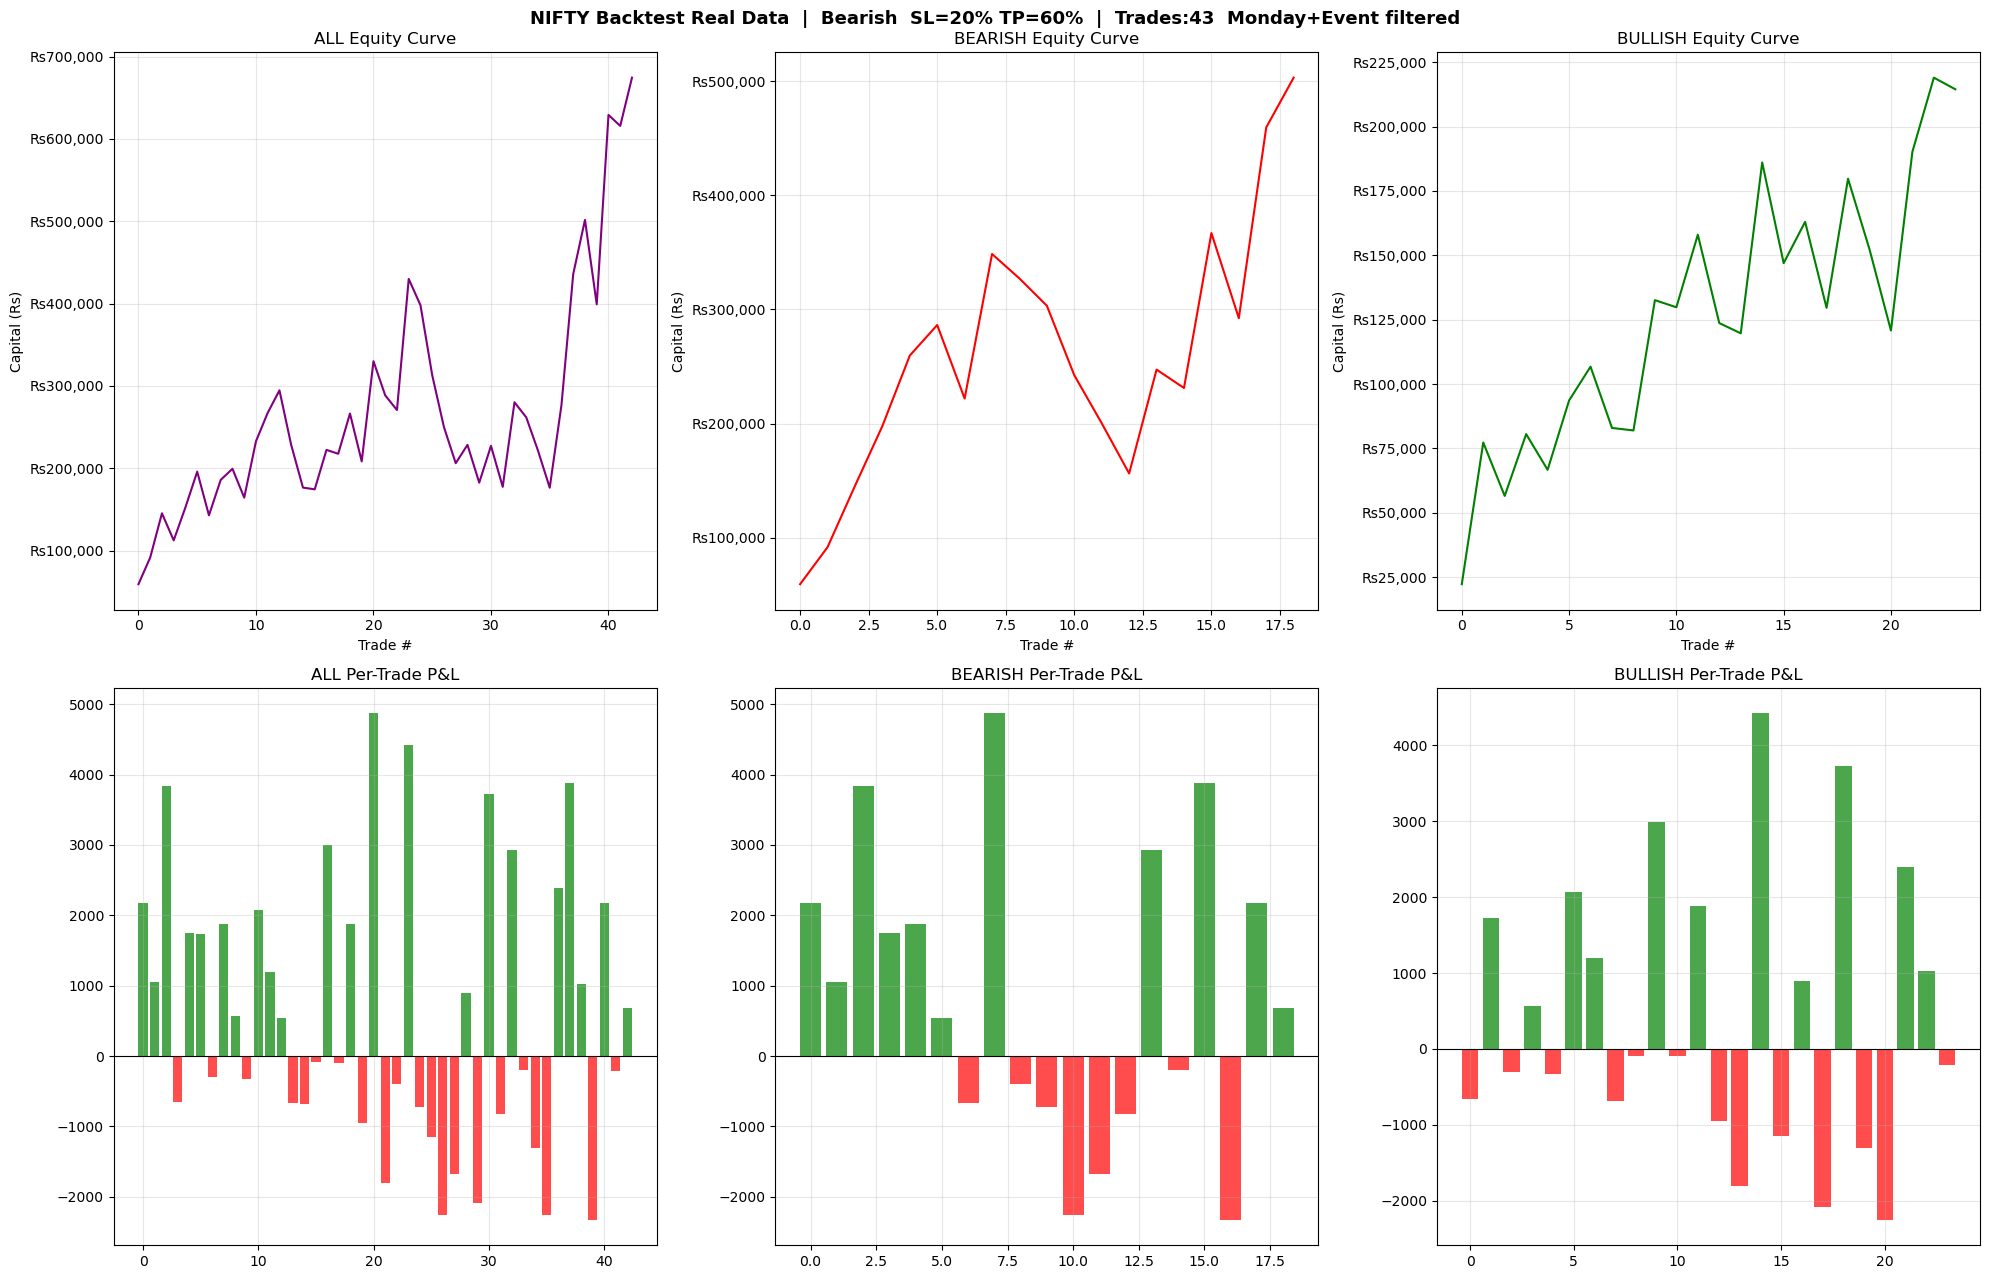

Chart saved: c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\backtesting_true_data\backtest_outputs\backtest_charts.png
Excel saved: c:\Users\sayan\OneDrive\Desktop\Projects\03_Market_Research\market-research\backtesting_true_data\backtest_outputs\backtest_report.xlsx

Done.  Trades:43  Mode:Bearish  SL=20%  TP=60%
Win rate  : 51.2%
Avg/trade : Rs642
Total P&L : Rs27,624


In [87]:
# Cell 6: Trade log + capital tracking + XIRR + Charts + Excel
pd.set_option('display.max_rows',200); pd.set_option('display.max_columns',25); pd.set_option('display.width',230)

if total_trades>0:
    sep='='*210
    hdr=f'Mode={SIGNAL_MODE}  SL={STOP_LOSS_PCT:.0%}  TP={PROFIT_TARGET_PCT:.0%}  {STRIKES_OTM}-OTM  Entry=NSE Bhav Open  Monday+Event filtered'
    print(sep); print(f"{'NIFTY OPTIONS BACKTEST — REAL NSE DATA':^210}"); print(f'{hdr:^210}'); print(sep)
    print(results_df[['Date','Signal','NIFTY Open','Gap%','Strike','DTE','IV%','Entry (pts)','Exit (pts)',
                       'Exit Reason','Exit Time','P&L (pts)','P&L (Rs)','Actual','Actual Ret%','Correct?']].to_string(index=False))
    print(sep)
    for lbl,sub in [('ALL',results_df),
                    ('BEARISH',results_df[results_df['Signal']=='BEARISH']),
                    ('BULLISH',results_df[results_df['Signal']=='BULLISH'])]:
        if not len(sub): continue
        print(f'  {lbl:<8}: {len(sub):>3} trades  '
              f'Win rate {(sub["P&L (Rs)"]>0).mean()*100:.1f}%  '
              f'Pred acc {(sub["Correct?"]=="YES").mean()*100:.1f}%  '
              f'Total P&L Rs{sub["P&L (Rs)"].sum():,.0f}  '
              f'Avg Rs{sub["P&L (Rs)"].mean():,.0f}')

def compute_xirr(cf, dates):
    try: return newton(lambda r: sum(c/((1+r)**((d-dates[0]).days/365.0)) for c,d in zip(cf,dates)), 0.1)
    except: return None

def metrics_block(df, label):
    if not len(df): print(f'  {label}: no trades.'); return [0.0], pd.DataFrame()
    capital=None; cap_curve=[]; FIXED=10; rc=0; tr=0.0; re=[]; cf=[]; cd=[]; sl=[]
    for i in range(len(df)):
        row=df.iloc[i]; td=pd.to_datetime(row['Date']); ep=float(row['Entry (pts)']); pp=float(row['P&L (pts)']); cpl=ep*LOT_SIZE
        if cpl<=0: continue
        if capital is None: capital=cpl*FIXED; ic=capital; cf.append(-ic); cd.append(td)
        cb=capital; req=cpl*FIXED; ra=0.0
        if cb<req: ra=req-cb; cb+=ra; capital=cb; rc+=1; tr+=ra; re.append((i,ra)); cf.append(-ra); cd.append(td)
        car=cb; unc=max(FIXED,int(car/cpl)); dv=int(row['DTE'])
        d0=min(unc,DTE0_MAX_LOTS) if dv==0 else unc; lots=min(d0,MAX_LOTS); lc=unc>lots
        cr=(f'DTE0 cap ({unc})' if dv==0 and unc>DTE0_MAX_LOTS else f'Global cap ({unc})') if lc else ''
        tp=pp*LOT_SIZE*lots-BROKERAGE*lots; capital=car+tp; cap_curve.append(round(capital,2))
        sl.append({'Trade #':i+1,'Date':td.date(),'Signal':row['Signal'],'Combo':row['Combo'],
            'NIFTY Open':row['NIFTY Open'],'Strike':row['Strike'],'Expiry':row['Expiry'],
            'DTE':row['DTE'],'IV%':row['IV%'],'Entry (pts)':ep,'Exit (pts)':float(row['Exit (pts)']),
            'P&L (pts)':pp,'Cost/lot(Rs)':round(cpl,2),'Uncapped Lots':unc,'Lots':lots,
            'Lot Cap?':'YES' if lc else 'no','Cap Reason':cr,
            'Capital Before':round(cb-ra,2),'Refill':round(ra,2),'Cap After Refill':round(car,2),
            'Trade P&L(Rs)':round(tp,2),'Capital After Trade':round(capital,2),
            'Cum Refill':round(tr,2),'Refill Count':rc,
            'Exit Reason':row['Exit Reason'],'Exit Time':row['Exit Time'],
            'Correct?':row['Correct?'],'Actual':row['Actual'],'Actual Ret%':row['Actual Ret%']})
    cf.append(capital); cd.append(pd.to_datetime(df.iloc[-1]['Date']))
    ti=ic+tr; net=(capital-ti)/ti*100 if ti>0 else 0; xirr=compute_xirr(cf,cd)
    print(f'\n{"="*58}\n  {label} — CAPITAL SUMMARY\n{"="*58}')
    print(f'  Initial capital : Rs{ic:,.0f}  |  Total invested: Rs{ti:,.0f}  |  Final: Rs{capital:,.0f}')
    print(f'  Net return      : {net:+.2f}%  |  XIRR: {xirr*100:.1f}%' if xirr else f'  Net return: {net:+.2f}%')
    print(f'  Refill count    : {rc}  |  Total refilled: Rs{tr:,.0f}')
    print(f'{"="*58}')
    if re: print('  Refills: '+' '.join(f'T{x+1}:+Rs{a:,.0f}' for x,a in re))
    return cap_curve, pd.DataFrame(sl)

curves={}; ledgers={}
bear_df=results_df[results_df['Signal']=='BEARISH'].reset_index(drop=True) if total_trades>0 else pd.DataFrame()
bull_df=results_df[results_df['Signal']=='BULLISH'].reset_index(drop=True) if total_trades>0 else pd.DataFrame()
curves['ALL'],     ledgers['ALL']     = metrics_block(results_df,'ALL TRADES')
curves['BEARISH'], ledgers['BEARISH'] = metrics_block(bear_df,   'BEARISH ONLY')
curves['BULLISH'], ledgers['BULLISH'] = metrics_block(bull_df,   'BULLISH ONLY')

# Charts
if total_trades>0:
    fig=plt.figure(figsize=(20,13)); gs=gridspec.GridSpec(2,3,figure=fig)
    subs={'ALL':results_df,'BEARISH':bear_df,'BULLISH':bull_df}
    for i,key in enumerate(['ALL','BEARISH','BULLISH']):
        ax=fig.add_subplot(gs[0,i]); cap=curves[key]
        if cap and cap!=[0.0]:
            ax.plot(cap,color='purple' if key=='ALL' else 'red' if key=='BEARISH' else 'green')
            ax.set_title(f'{key} Equity Curve'); ax.set_xlabel('Trade #'); ax.set_ylabel('Capital (Rs)')
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'Rs{x:,.0f}')); ax.grid(True,alpha=0.3)
    for i,key in enumerate(['ALL','BEARISH','BULLISH']):
        ax=fig.add_subplot(gs[1,i]); sub=subs[key]
        if len(sub)>0:
            ax.bar(range(len(sub)),sub['P&L (Rs)'],color=['green' if p>0 else 'red' for p in sub['P&L (Rs)']],alpha=0.7)
            ax.axhline(0,color='black',lw=0.8); ax.set_title(f'{key} Per-Trade P&L'); ax.grid(True,alpha=0.3)
    fig.suptitle(
        f'NIFTY Backtest Real Data  |  {SIGNAL_MODE}  SL={STOP_LOSS_PCT:.0%} TP={PROFIT_TARGET_PCT:.0%}  |  '
        f'Trades:{total_trades}  Monday+Event filtered',
        fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/'backtest_charts.png',dpi=150,bbox_inches='tight'); plt.show()
    print(f'Chart saved: {OUTPUT_DIR/"backtest_charts.png"}')

# Excel
output_file=OUTPUT_DIR/'backtest_report.xlsx'
try:
    import openpyxl
    with pd.ExcelWriter(output_file,engine='openpyxl') as writer:
        pd.DataFrame([{'Parameter':k,'Value':v} for k,v in [
            ('SIGNAL_MODE',SIGNAL_MODE),('STOP_LOSS_PCT',f'{STOP_LOSS_PCT:.0%}'),
            ('PROFIT_TARGET_PCT',f'{PROFIT_TARGET_PCT:.0%}'),('BACKTEST_DAYS',BACKTEST_DAYS),
            ('DTE0_MAX_LOTS',DTE0_MAX_LOTS),('MAX_LOTS',MAX_LOTS),('LOT_SIZE',LOT_SIZE),
            ('STRIKES_OTM',STRIKES_OTM),('Backtest start',str(start_date)),('Backtest end',str(end_date)),
            ('Trades simulated',total_trades),('Skipped (no bhav)',skipped_no_bhav),
            ('Monday filtered',skipped_monday),('Event filtered',skipped_event),
            ('Entry source','NSE F&O Bhav Copy (real OPEN)'),
            ('Exit method','NIFTY spot minute + real IV (BS path)'),
        ]]).to_excel(writer,sheet_name='Config',index=False)
        if total_trades>0: results_df.to_excel(writer,sheet_name='Trade Log',index=False)
        for key,sheet in [('ALL','Session Ledger (ALL)'),('BEARISH','Session Ledger (BEAR)'),('BULLISH','Session Ledger (BULL)')]:
            if key in ledgers and len(ledgers[key])>0: ledgers[key].to_excel(writer,sheet_name=sheet,index=False)
        rows=[]
        for key in ['ALL','BEARISH','BULLISH']:
            sub=results_df if key=='ALL' else (bear_df if key=='BEARISH' else bull_df)
            if not len(sub): continue
            wins=(sub['P&L (Rs)']>0).sum(); led=ledgers.get(key)
            rows.append({'Type':key,'Trades':len(sub),'Wins':int(wins),
                'Win Rate %':round(wins/len(sub)*100,2),
                'Pred Accuracy %':round((sub['Correct?']=='YES').mean()*100,2),
                'Avg P&L/trade (Rs)':round(sub['P&L (Rs)'].mean(),2),
                'Total PnL 1-lot (Rs)':round(sub['P&L (Rs)'].sum(),2),
                'Final Capital (Rs)':round(led['Capital After Trade'].iloc[-1],2) if led is not None and len(led)>0 else 'N/A'})
        pd.DataFrame(rows).to_excel(writer,sheet_name='Summary',index=False)
        ed={k:pd.Series(v,name=k) for k,v in curves.items() if v and v!=[0.0]}
        if ed: pd.concat(ed.values(),axis=1).to_excel(writer,sheet_name='Equity Curves',index=True)
    print(f'Excel saved: {output_file}')
except ImportError:
    if total_trades>0: results_df.to_csv(OUTPUT_DIR/'backtest_report.csv',index=False); print('CSV saved (openpyxl missing)')

print(f'\nDone.  Trades:{total_trades}  Mode:{SIGNAL_MODE}  SL={STOP_LOSS_PCT:.0%}  TP={PROFIT_TARGET_PCT:.0%}')
if total_trades>0:
    print(f'Win rate  : {(results_df["P&L (Rs)"]>0).mean()*100:.1f}%')
    print(f'Avg/trade : Rs{results_df["P&L (Rs)"].mean():,.0f}')
    print(f'Total P&L : Rs{results_df["P&L (Rs)"].sum():,.0f}')